## ⚙️ 공통 환경 설정 (가장 먼저 실행하세요!)

In [6]:
# =====================================================
# 공통 설정: 모든 예제에서 사용하는 라이브러리 한 번에 설치/로드
# =====================================================

# ── Colab 전용: 한글 폰트 설치 ──
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

# ── 필요한 라이브러리 불러오기 ──
import numpy as np              # 수치 계산
import pandas as pd             # 데이터 표(DataFrame) 처리
import matplotlib.pyplot as plt # 그래프 그리기
import seaborn as sns           # 고급 통계 그래프
import warnings
warnings.filterwarnings('ignore')

print("✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.")
print(f"   NumPy  버전: {np.__version__}")
print(f"   Pandas 버전: {pd.__version__}")


Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.
   NumPy  버전: 2.0.2
   Pandas 버전: 2.2.2


---
## 예제 4: 머신러닝 기반 공정 이상탐지 ⭐⭐⭐ 중급

### 🏭 배경 설명

GMP 공정에는 수십~수백 개의 파라미터가 동시에 변동합니다. 전통적인 SPC는 파라미터를
**하나씩** 모니터링하지만, 머신러닝 기반 **이상탐지(Anomaly Detection)**는 여러 파라미터의
**복잡한 상호관계**까지 고려하여 더 정교하게 이상 배치를 찾아냅니다.

**Isolation Forest 알고리즘 원리:**
- 정상 데이터는 여러 파라미터에서 비슷한 패턴을 보입니다
- 이상 데이터(비정상 배치)는 다른 배치들과 **고립(isolated)**되어 있습니다
- 데이터를 무작위로 분할했을 때 **빨리 고립될수록** 이상 배치일 가능성이 높습니다
- 별도의 정답(라벨) 없이 작동하는 **비지도학습** 방법입니다

**이 예제에서 배우는 것:**
- 다변수 공정 데이터 생성 및 전처리
- Isolation Forest로 이상 배치 자동 탐지
- 이상 점수(Anomaly Score) 시각화 및 해석
- 실제 고장 원인과 이상 점수 비교

**가상 시나리오:** 동결건조 주사제 제조 공정의 6가지 파라미터를 동시에 모니터링합니다.


---
## 📍 모듈 ② — 예측적 품질관리 | 예제 4: 공정 이상 탐지

### 🏛️ GMP 커버리지
| 규정 / 가이드라인 | 이 예제에서의 적용 |
|----------------|-----------------|
| **ICH Q9 품질 리스크 관리** | 이상 배치 = 리스크 이벤트 → AI로 자동 식별·우선순위화 |
| **21 CFR 211.192 편차 조사** | Isolation Forest 이상 점수 → Deviation Report 트리거 기준 |
| **EU GMP Annex 11** | 전산화 시스템 검증 — AI 이상탐지 모델도 검증 대상 |
| **동결건조(Lyophilization) 공정** | 3단계(냉동·1차건조·2차건조) 각 6개 파라미터 다변량 감시 |

### 🤖 AI 도입 장점
| 전통 방법 | AI / 데이터 과학 방법 | 개선 효과 |
|---------|-------------------|---------|
| 파라미터 1개씩 한계치(limit) 비교 | **Isolation Forest**: 6개 변수 조합의 이상 판단 | 단일 변수론 보이지 않는 다변량 이상 감지 |
| 이상 데이터 레이블 필요 | 정상 데이터만으로 학습 (비지도) | 레이블링 비용 제로, 신규 이상 유형도 탐지 |
| 분석가가 기준치 수동 설정 | 데이터 분포에서 자동으로 경계 학습 | 공정 변경 시 자동 재보정 가능 |

### 🎯 핵심 Takeaway
> **"비지도 학습으로도 레이블 없이 이상치를 찾을 수 있다."**

1. **Isolation Forest의 역발상**: "이상 데이터는 정상보다 고립(isolate)하기 쉽다"  
   → 분리에 필요한 랜덤 분기 수가 적을수록 이상 점수 높음
2. **PCA 2D 시각화**: 6차원 공정 데이터를 2차원으로 줄여도 정상/이상 군집이 분리됨  
   → 고차원 공정 데이터의 구조를 직관적으로 이해하는 핵심 도구
3. 이상탐지 모델의 임계값(threshold) 설정은 **False Positive vs False Negative 트레이드오프**  
   → GMP에서는 False Negative(이상 미탐지)가 더 위험 → 임계값을 보수적으로 설정

### ➡️ 다음 예제
**예제 5 (Deviation 분류)**: 감지된 이상이 어떤 **편차 유형**인지 AI로 자동 분류 → CAPA 연결

### 🧊 동결건조(Lyophilization / Freeze-Drying) 공정 이해

동결건조는 생물의약품(단백질 의약품, mRNA 백신 등)의 장기 안정성을 확보하기 위한 핵심 GMP 공정입니다.

#### 공정 3단계
```
① 동결(Freezing)          ② 1차 건조(Primary Drying)     ③ 2차 건조(Secondary Drying)
─────────────────          ──────────────────────────       ──────────────────────────────
제품을 -40~-50°C로          진공 상태에서 얼음을              결합수(bound water)까지 제거
급속 동결                   승화(고체 → 기체)로 제거          수분 함량 1% 이하로 감소
(결정 구조 유지)             주요 에너지 소비 단계             최종 제품 안정성 확보
```

#### 6개 핵심 모니터링 파라미터

| 파라미터 | 정상 범위 | 이상 발생 시 결과 |
|---------|-----------|-----------------|
| **선반 온도** (shelf_temp_C) | -40 ± 2°C | 너무 높으면: 제품 용융(Meltback) |
| **챔버 압력** (chamber_pressure) | 0.10 ± 0.02 mbar | 너무 높으면: 승화 속도 저하 |
| **콘덴서 온도** (condenser_temp_C) | -60 ± 3°C | 너무 높으면: 수증기 포집 실패 |
| **제품 온도** (product_temp_C) | -35 ± 2°C | 너무 높으면: 케이크 붕괴(Collapse) |
| **건조 시간** (drying_time_h) | 24 ± 2h | 너무 짧으면: 잔류 수분 증가 |
| **잔류 수분** (moisture_pct) | 1.5 ± 0.3% | OOS 기준: 보통 3% 초과 시 기각 |

#### 왜 AI 이상탐지가 필요한가?
전통적인 SPC는 파라미터를 **하나씩** 모니터링하지만,
동결건조 실패는 **여러 파라미터가 동시에 미묘하게 변동**할 때 발생합니다.
→ Isolation Forest는 **6개 파라미터를 동시에** 분석하여 패턴 이상을 탐지합니다.

In [7]:
# =====================================================
# 예제 4: 머신러닝 기반 공정 이상탐지
# Isolation Forest 알고리즘 사용
# =====================================================

from sklearn.ensemble import IsolationForest    # 이상탐지 알고리즘
from sklearn.preprocessing import StandardScaler # 데이터 표준화 도구
from sklearn.decomposition import PCA            # 차원 축소 도구 (시각화용)

# ─────────────────────────────────────────────────────
# 4-1. 동결건조 공정 다변수 데이터 생성
# 6개 공정 파라미터를 동시에 모니터링하는 상황
# ─────────────────────────────────────────────────────

np.random.seed(2026)
n_normal = 1800    # 정상 배치 수
n_anom   = 200     # 이상 배치 수 (전체의 약 10%)

# 정상 배치 데이터 (6개 파라미터)
normal_batches = {
    'shelf_temp_C'    : np.random.normal(-40, 1.0, n_normal),  # 선반 온도 (°C)
    'chamber_pressure': np.random.normal(0.1,  0.01, n_normal), # 챔버 압력 (mbar)
    'condenser_temp_C': np.random.normal(-60, 2.0, n_normal),  # 콘덴서 온도 (°C)
    'product_temp_C'  : np.random.normal(-35, 1.5, n_normal),  # 제품 온도 (°C)
    'drying_time_h'   : np.random.normal(24,   1.0, n_normal),  # 건조 시간 (h)
    'moisture_pct'    : np.random.normal(1.5,  0.2, n_normal),  # 잔류 수분 (%)
}

# 이상 배치 데이터 (파라미터가 정상 범위를 크게 벗어남)
anomaly_batches = {
    'shelf_temp_C'    : np.random.normal(-37, 2.0, n_anom),   # 선반 온도 이상 (높음)
    'chamber_pressure': np.random.normal(0.12, 0.05, n_anom), # 압력 이상 (높음)
    'condenser_temp_C': np.random.normal(-56, 4.0, n_anom),   # 콘덴서 온도 이상
    'product_temp_C'  : np.random.normal(-32, 3.0, n_anom),   # 제품 온도 이상 (높음)
    'drying_time_h'   : np.random.normal(22,   2.0, n_anom),  # 건조 시간 부족
    'moisture_pct'    : np.random.normal(2.1,  0.3, n_anom),  # 수분 함량 높음
}
# anomaly_batches = {
#     'shelf_temp_C'    : np.random.normal(-35, 3.0, n_anom),   # 선반 온도 이상 (높음)
#     'chamber_pressure': np.random.normal(0.15, 0.05, n_anom), # 압력 이상 (높음)
#     'condenser_temp_C': np.random.normal(-50, 5.0, n_anom),   # 콘덴서 온도 이상
#     'product_temp_C'  : np.random.normal(-28, 4.0, n_anom),   # 제품 온도 이상 (높음)
#     'drying_time_h'   : np.random.normal(20,   3.0, n_anom),  # 건조 시간 부족
#     'moisture_pct'    : np.random.normal(3.5,  1.0, n_anom),  # 수분 함량 높음
# }

# 두 데이터를 합쳐서 하나의 데이터프레임으로 만들기
df_normal = pd.DataFrame(normal_batches)
df_anom   = pd.DataFrame(anomaly_batches)
df_lyoph  = pd.concat([df_normal, df_anom], ignore_index=True)

# 정답 라벨 (실제 업무에서는 없을 수 있음 - 검증용으로만 사용)
df_lyoph['true_label'] = ['정상']*n_normal + ['이상']*n_anom

# 데이터 섞기 (실제처럼 순서를 알 수 없도록)
df_lyoph = df_lyoph.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"📊 동결건조 공정 데이터: 총 {len(df_lyoph)}배치 (정상 {n_normal} + 이상 {n_anom})")
print(f"   모니터링 파라미터: {len(df_lyoph.columns)-1}개")
df_lyoph.head()


📊 동결건조 공정 데이터: 총 2000배치 (정상 1800 + 이상 200)
   모니터링 파라미터: 6개


,shelf_temp_C,chamber_pressure,condenser_temp_C,product_temp_C,drying_time_h,moisture_pct,true_label
0,-33.869914,0.144552,-53.615309,-31.235481,23.670680,2.897267,이상
1,-40.079737,0.119392,-57.347212,-35.853757,24.969993,1.307729,정상
2,-40.236555,0.120026,-59.118335,-34.640216,23.565799,1.358741,정상
3,-40.587515,0.086542,-60.883503,-31.671764,23.643747,1.321207,정상
4,-40.318030,0.110750,-62.832572,-33.546620,24.924568,1.456606,정상


### 📐 PCA(주성분분석)란? — 6차원을 눈에 보이는 2D로!

#### 문제 상황
6개 파라미터를 동시에 시각화하려면 **6차원 공간**이 필요 → 사람 눈으로 볼 수 없음

#### 해결책: PCA (Principal Component Analysis, 주성분분석)
- 데이터의 **핵심 정보(분산)를 최대한 보존**하면서 차원을 줄여줍니다
- 6차원 → 2차원으로 압축 → **2D 그래프로 시각화 가능!**
- 각 새 축(주성분)은 원래 변수들의 선형 조합

```
원래 데이터 (6차원)                PCA 변환 후 (2차원)
──────────────────                 ────────────────────────────────
shelf_temp_C    ┐                  PC1 (주성분1): 데이터 변동을
chamber_pressure│                         가장 많이 설명하는 방향
condenser_temp_C│   →  PCA  →
product_temp_C  │                  PC2 (주성분2): PC1과 수직 방향,
drying_time_h   │                         두 번째로 많이 설명
moisture_pct    ┘
```

**핵심 포인트:**
- PC1 + PC2 두 개만으로 전체 분산의 60~80%를 설명하는 경우가 많음
- 이상 배치(빨간 점)가 정상 배치 군집에서 **눈에 띄게 분리**되면 탐지 성공
- 아래 셀에서 실제로 확인해봅니다 👇

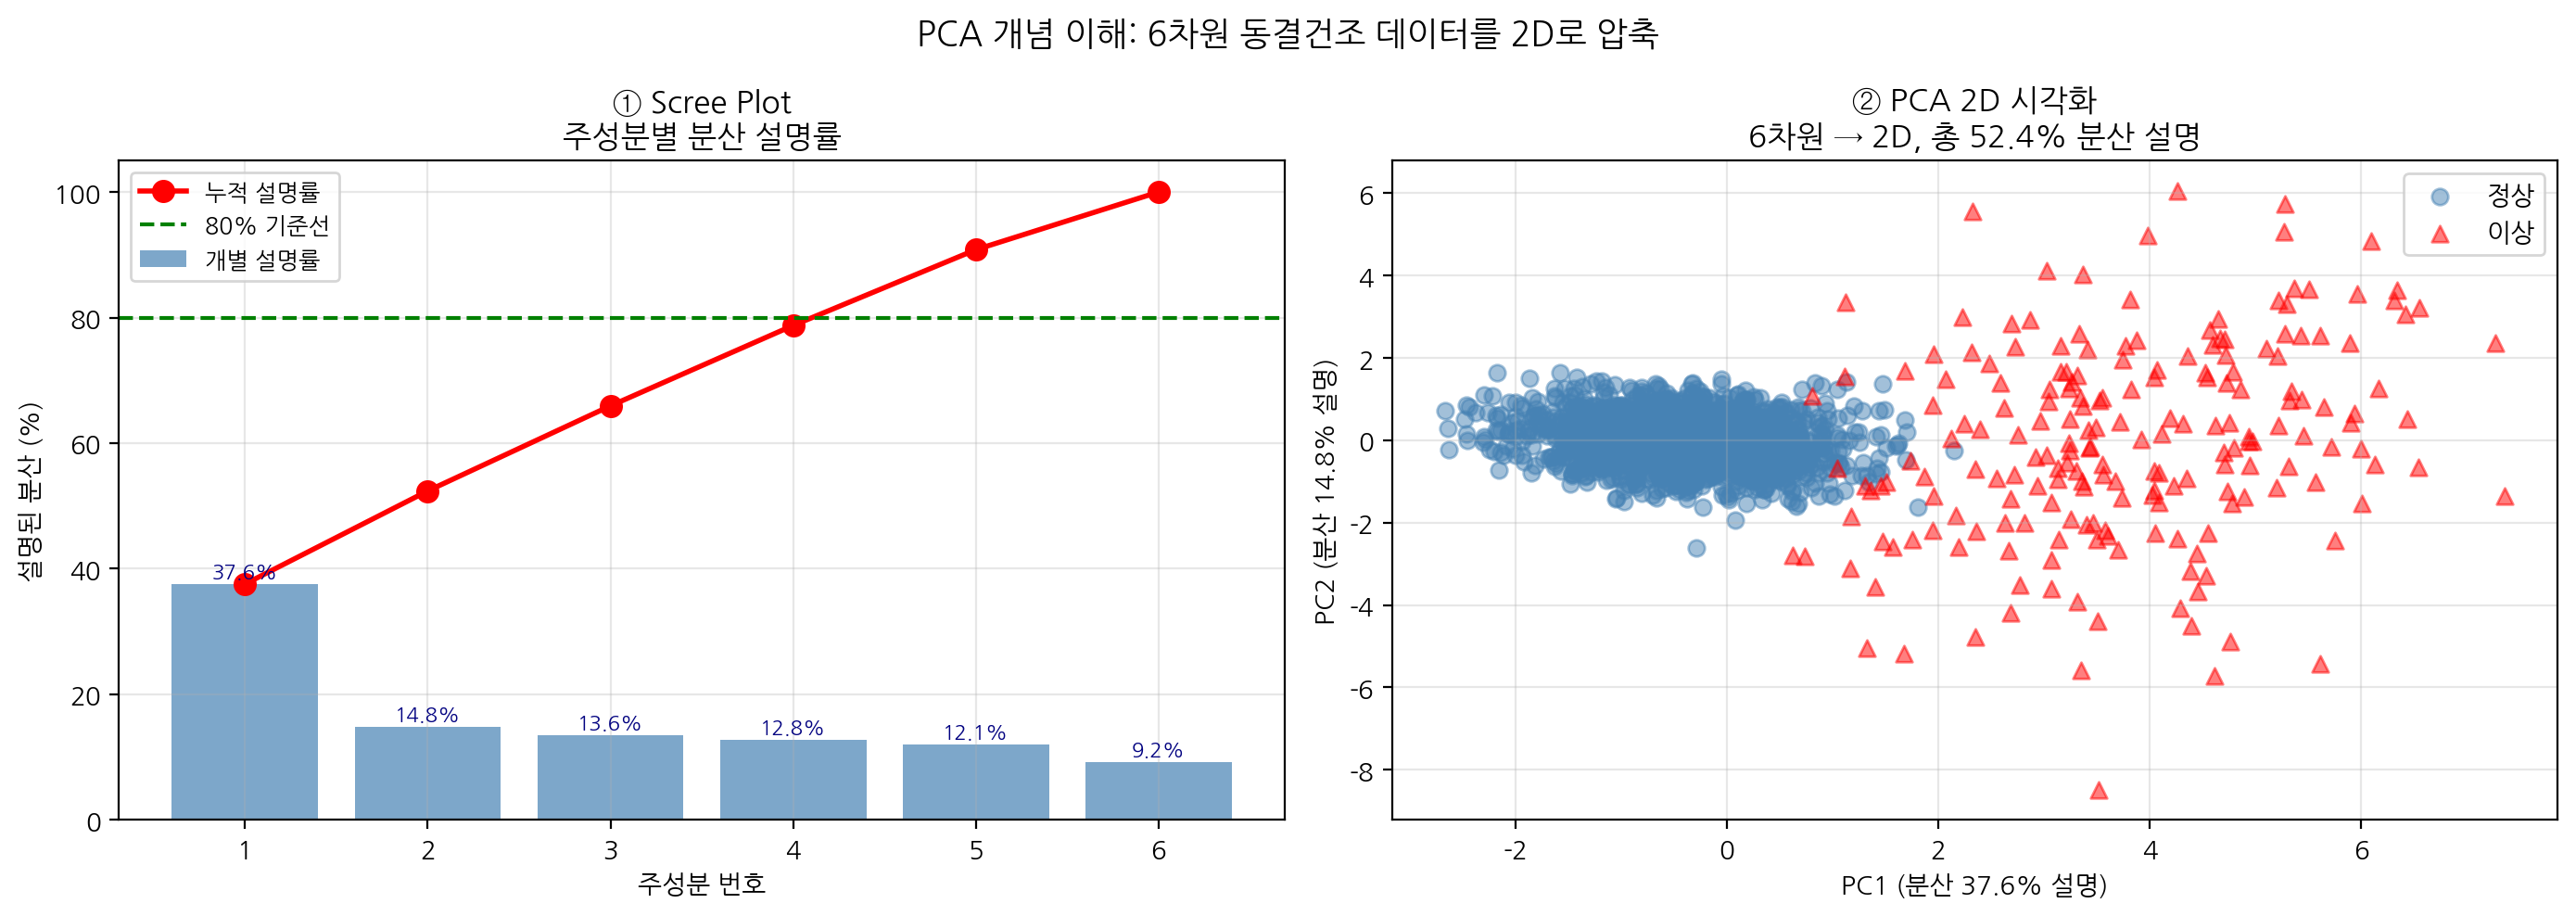

✅ PCA 개념 예제 완료!
   PC1+PC2 두 축만으로 전체 데이터 분산의 52.4%를 설명합니다.
   → 2D 그래프만으로도 6D 데이터의 핵심 패턴(이상 vs 정상 분리)을 볼 수 있습니다.
   (이상 배치가 2D에서 정상 군집과 분리될수록 탐지가 쉬워집니다)


In [9]:
# ─────────────────────────────────────────────────────
# 4-A. PCA 개념 예제: 6차원 → 2D 시각화 원리 이해
# ─────────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # Added: Import StandardScaler

# ── 입력 데이터 준비 ──
feature_cols = ['shelf_temp_C', 'chamber_pressure', 'condenser_temp_C',
                'product_temp_C', 'drying_time_h', 'moisture_pct']
X = df_lyoph[feature_cols]   # 6개 파라미터만 선택 (라벨 제외)

# ── 표준 스케일링 ──
# 각 파라미터의 단위가 달라서 그대로 쓰면 비교가 어렵습니다
# StandardScaler: 각 변수의 평균=0, 표준편차=1로 변환
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)    # fit: 평균/표준편차 계산, transform: 변환 적용

# ① 6개 주성분 전체로 분석: 각 주성분이 분산을 얼마나 설명하는가?
pca_full = PCA(n_components=6)
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA 개념 이해: 6차원 동결건조 데이터를 2D로 압축', fontsize=13, fontweight='bold')

# 그래프 ①: Scree Plot — 주성분별 설명 분산 비율
ax = axes[0]
exp_var = pca_full.explained_variance_ratio_ * 100
cum_var = np.cumsum(exp_var)
ax.bar(range(1, 7), exp_var, color='steelblue', alpha=0.7, label='개별 설명률')
ax.plot(range(1, 7), cum_var, 'ro-', lw=2, ms=8, label='누적 설명률')
ax.axhline(80, color='green', ls='--', lw=1.5, label='80% 기준선')
ax.set_xlabel('주성분 번호'); ax.set_ylabel('설명된 분산 (%)')
ax.set_title('① Scree Plot\n주성분별 분산 설명률')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
for i, (v, c) in enumerate(zip(exp_var, cum_var)):
    ax.text(i+1, v+1, f'{v:.1f}%', ha='center', fontsize=8, color='navy')

# 그래프 ②: PCA 2D 결과 — 정상 vs 이상 군집 확인
ax = axes[1]
pca_2d = PCA(n_components=2)
X_2d_pca = pca_2d.fit_transform(X_scaled)

for label, color, marker in [('정상','steelblue','o'),('이상','red','^')]:
    mask = df_lyoph['true_label'] == label
    ax.scatter(X_2d_pca[mask, 0], X_2d_pca[mask, 1],
               c=color, label=label, alpha=0.5, s=40, marker=marker)

v1 = pca_2d.explained_variance_ratio_[0]*100
v2 = pca_2d.explained_variance_ratio_[1]*100
ax.set_xlabel(f'PC1 (분산 {v1:.1f}% 설명)')
ax.set_ylabel(f'PC2 (분산 {v2:.1f}% 설명)')
ax.set_title(f'② PCA 2D 시각화\n6차원 → 2D, 총 {v1+v2:.1f}% 분산 설명')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ PCA 개념 예제 완료!")
print(f"   PC1+PC2 두 축만으로 전체 데이터 분산의 {v1+v2:.1f}%를 설명합니다.")
print(f"   → 2D 그래프만으로도 6D 데이터의 핵심 패턴(이상 vs 정상 분리)을 볼 수 있습니다.")
print(f"   (이상 배치가 2D에서 정상 군집과 분리될수록 탐지가 쉬워집니다)")

In [10]:
# ─────────────────────────────────────────────────────
# 4-2. 데이터 표준화 및 Isolation Forest 모델 학습
# ─────────────────────────────────────────────────────

# ── 입력 데이터 준비 ──
feature_cols = ['shelf_temp_C', 'chamber_pressure', 'condenser_temp_C',
                'product_temp_C', 'drying_time_h', 'moisture_pct']
X = df_lyoph[feature_cols]   # 6개 파라미터만 선택 (라벨 제외)

# ── 표준 스케일링 ──
# 각 파라미터의 단위가 달라서 그대로 쓰면 비교가 어렵습니다
# StandardScaler: 각 변수의 평균=0, 표준편차=1로 변환
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)    # fit: 평균/표준편차 계산, transform: 변환 적용

print("표준화 전 데이터 (예: 선반온도):", X['shelf_temp_C'].describe().round(2).to_dict())
print("표준화 후 평균:", X_scaled[:, 0].mean().round(4), "  표준편차:", X_scaled[:, 0].std().round(4))

# ── Isolation Forest 모델 학습 ──
# contamination: 이상 데이터가 전체의 몇 %인지 예상 비율 지정
iso_forest = IsolationForest(
    n_estimators=100,          # 결정 트리를 100개 만들어 앙상블
    contamination=0.1,         # 이상 데이터 예상 비율: 10%
    random_state=42            # 재현성을 위한 난수 고정
)

# 모델 학습 (정답 라벨 없이 데이터 자체에서 패턴 학습)
iso_forest.fit(X_scaled)

# ── 예측 및 이상 점수 계산 ──
# predict: +1=정상, -1=이상
df_lyoph['prediction'] = iso_forest.predict(X_scaled)
df_lyoph['pred_label'] = df_lyoph['prediction'].map({1: '정상', -1: '이상'})

# score_samples: 이상 점수 (값이 낮을수록 더 이상함)
# 부호를 바꿔서 '이상 점수' (높을수록 더 이상함)로 변환
df_lyoph['anomaly_score'] = -iso_forest.score_samples(X_scaled)

print("\n📊 이상탐지 결과:")
print(df_lyoph['pred_label'].value_counts().to_string())


표준화 전 데이터 (예: 선반온도): {'count': 2000.0, 'mean': -39.64, 'std': 1.49, 'min': -43.47, '25%': -40.57, '50%': -39.86, '75%': -38.98, 'max': -31.57}
표준화 후 평균: 0.0   표준편차: 1.0

📊 이상탐지 결과:
pred_label
정상    1800
이상     200


📈 이상탐지 성능 평가
              precision    recall  f1-score   support

          이상       0.94      0.94      0.94       200
          정상       0.99      0.99      0.99      1800

    accuracy                           0.99      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.99      0.99      0.99      2000



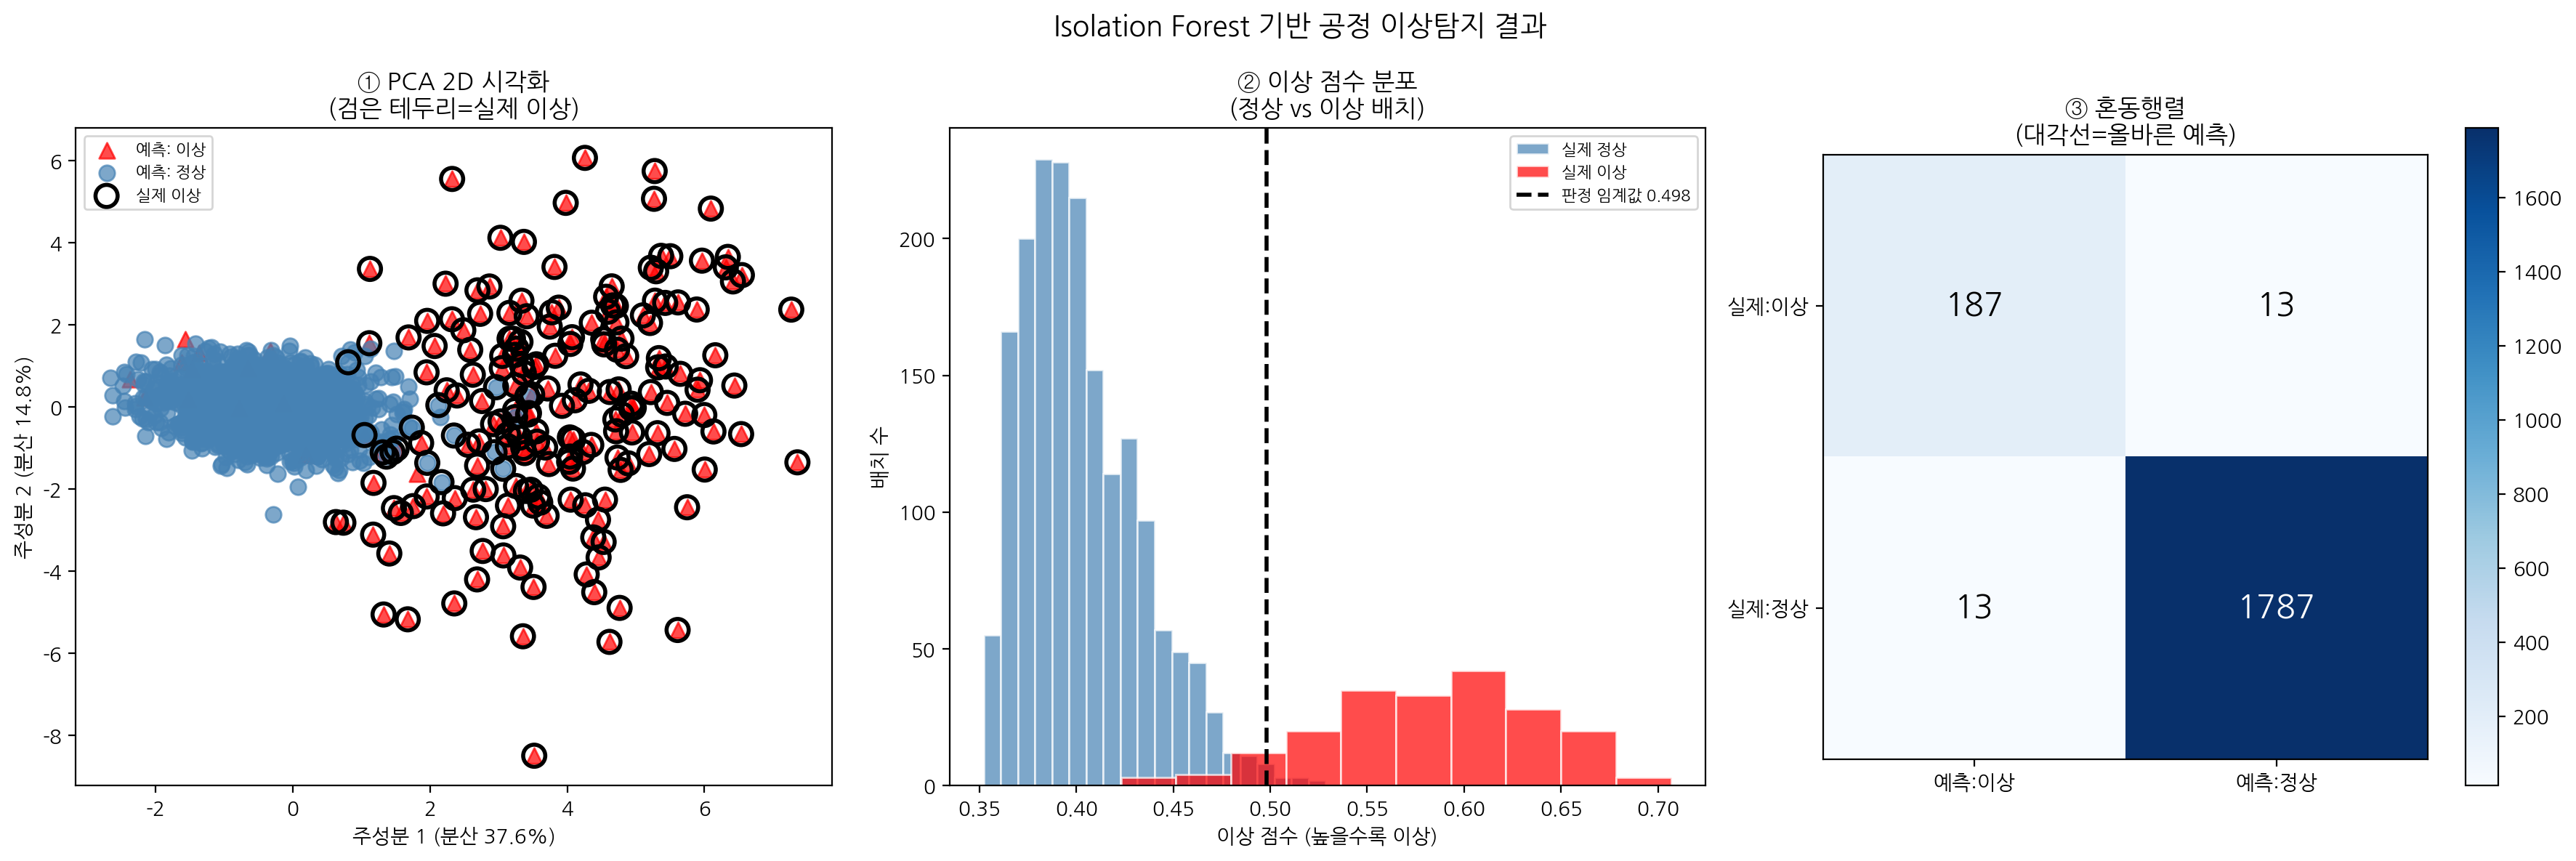


✅ 예제 4 완료!
   실제 이상 200배치 중 187배치(94%) 탐지 성공
📌 핵심 인사이트: 6개 파라미터를 동시에 분석하여 단일 파라미터 관리도로 놓친 이상 배치까지 탐지합니다.


In [11]:
# ─────────────────────────────────────────────────────
# 4-3. 탐지 성능 평가 및 시각화
# ─────────────────────────────────────────────────────

from sklearn.metrics import classification_report, confusion_matrix

# ── 성능 평가 ──
print("=" * 50)
print("📈 이상탐지 성능 평가")
print("=" * 50)
# 정답(true_label)과 예측(pred_label)을 비교
print(classification_report(df_lyoph['true_label'], df_lyoph['pred_label'],
                             target_names=['이상', '정상']))

# ── 시각화 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Isolation Forest 기반 공정 이상탐지 결과', fontsize=14, fontweight='bold')

# 그래프 ①: PCA로 2D 시각화 (6차원 → 2차원으로 압축)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)   # 6개 변수 → 2개 주성분으로 압축

ax = axes[0]
colors = {'이상': 'red', '정상': 'steelblue'}
for label, group in df_lyoph.groupby('pred_label'):
    idx = df_lyoph[df_lyoph['pred_label'] == label].index
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               c=colors[label], label=f'예측: {label}', alpha=0.7, s=60,
               marker='^' if label == '이상' else 'o')

# 실제 이상 배치에 검은 테두리 표시
real_anom_idx = df_lyoph[df_lyoph['true_label'] == '이상'].index
ax.scatter(X_2d[real_anom_idx, 0], X_2d[real_anom_idx, 1],
           s=120, facecolors='none', edgecolors='black', linewidths=2, label='실제 이상')
ax.set_xlabel(f'주성분 1 (분산 {pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'주성분 2 (분산 {pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('① PCA 2D 시각화\n(검은 테두리=실제 이상)')
ax.legend(fontsize=8)

# 그래프 ②: 이상 점수 분포
ax = axes[1]
ax.hist(df_lyoph[df_lyoph['true_label']=='정상']['anomaly_score'],
        bins=20, alpha=0.7, color='steelblue', label='실제 정상', edgecolor='white')
ax.hist(df_lyoph[df_lyoph['true_label']=='이상']['anomaly_score'],
        bins=10, alpha=0.7, color='red', label='실제 이상', edgecolor='white')
threshold = df_lyoph[df_lyoph['pred_label']=='이상']['anomaly_score'].min()
ax.axvline(threshold, color='black', ls='--', lw=2, label=f'판정 임계값 {threshold:.3f}')
ax.set_xlabel('이상 점수 (높을수록 이상)')
ax.set_ylabel('배치 수')
ax.set_title('② 이상 점수 분포\n(정상 vs 이상 배치)')
ax.legend(fontsize=8)

# 그래프 ③: 혼동행렬 (Confusion Matrix)
ax = axes[2]
cm = confusion_matrix(df_lyoph['true_label'], df_lyoph['pred_label'],
                      labels=['이상', '정상'])
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
labels = ['이상', '정상']
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['예측:이상', '예측:정상'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['실제:이상', '실제:정상'])
ax.set_title('③ 혼동행렬\n(대각선=올바른 예측)')

plt.tight_layout()
plt.savefig('예제4_이상탐지.png', dpi=150, bbox_inches='tight')
plt.show()

# 탐지 성능 요약
n_detected = ((df_lyoph['true_label']=='이상') & (df_lyoph['pred_label']=='이상')).sum()
print(f"\n✅ 예제 4 완료!")
print(f"   실제 이상 {n_anom}배치 중 {n_detected}배치({n_detected/n_anom*100:.0f}%) 탐지 성공")
print("📌 핵심 인사이트: 6개 파라미터를 동시에 분석하여 단일 파라미터 관리도로 놓친 이상 배치까지 탐지합니다.")


### 🌟 Isolation Forest 2D 시각화: 2개 파라미터로 동작 원리 이해하기

Isolation Forest가 2차원 공간에서 어떻게 이상치를 고립시키는지 이해하기 위해 `shelf_temp_C`와 `moisture_pct` 두 가지 파라미터만 사용해 시각화합니다. Isolation Forest는 데이터를 무작위로 분할하여 이상치를 빠르게 고립시키는 방식입니다. 아래 그림에서 색상의 변화(이상 점수)와 함께 데이터 포인트들이 어떻게 고립되는지 확인해 보세요.

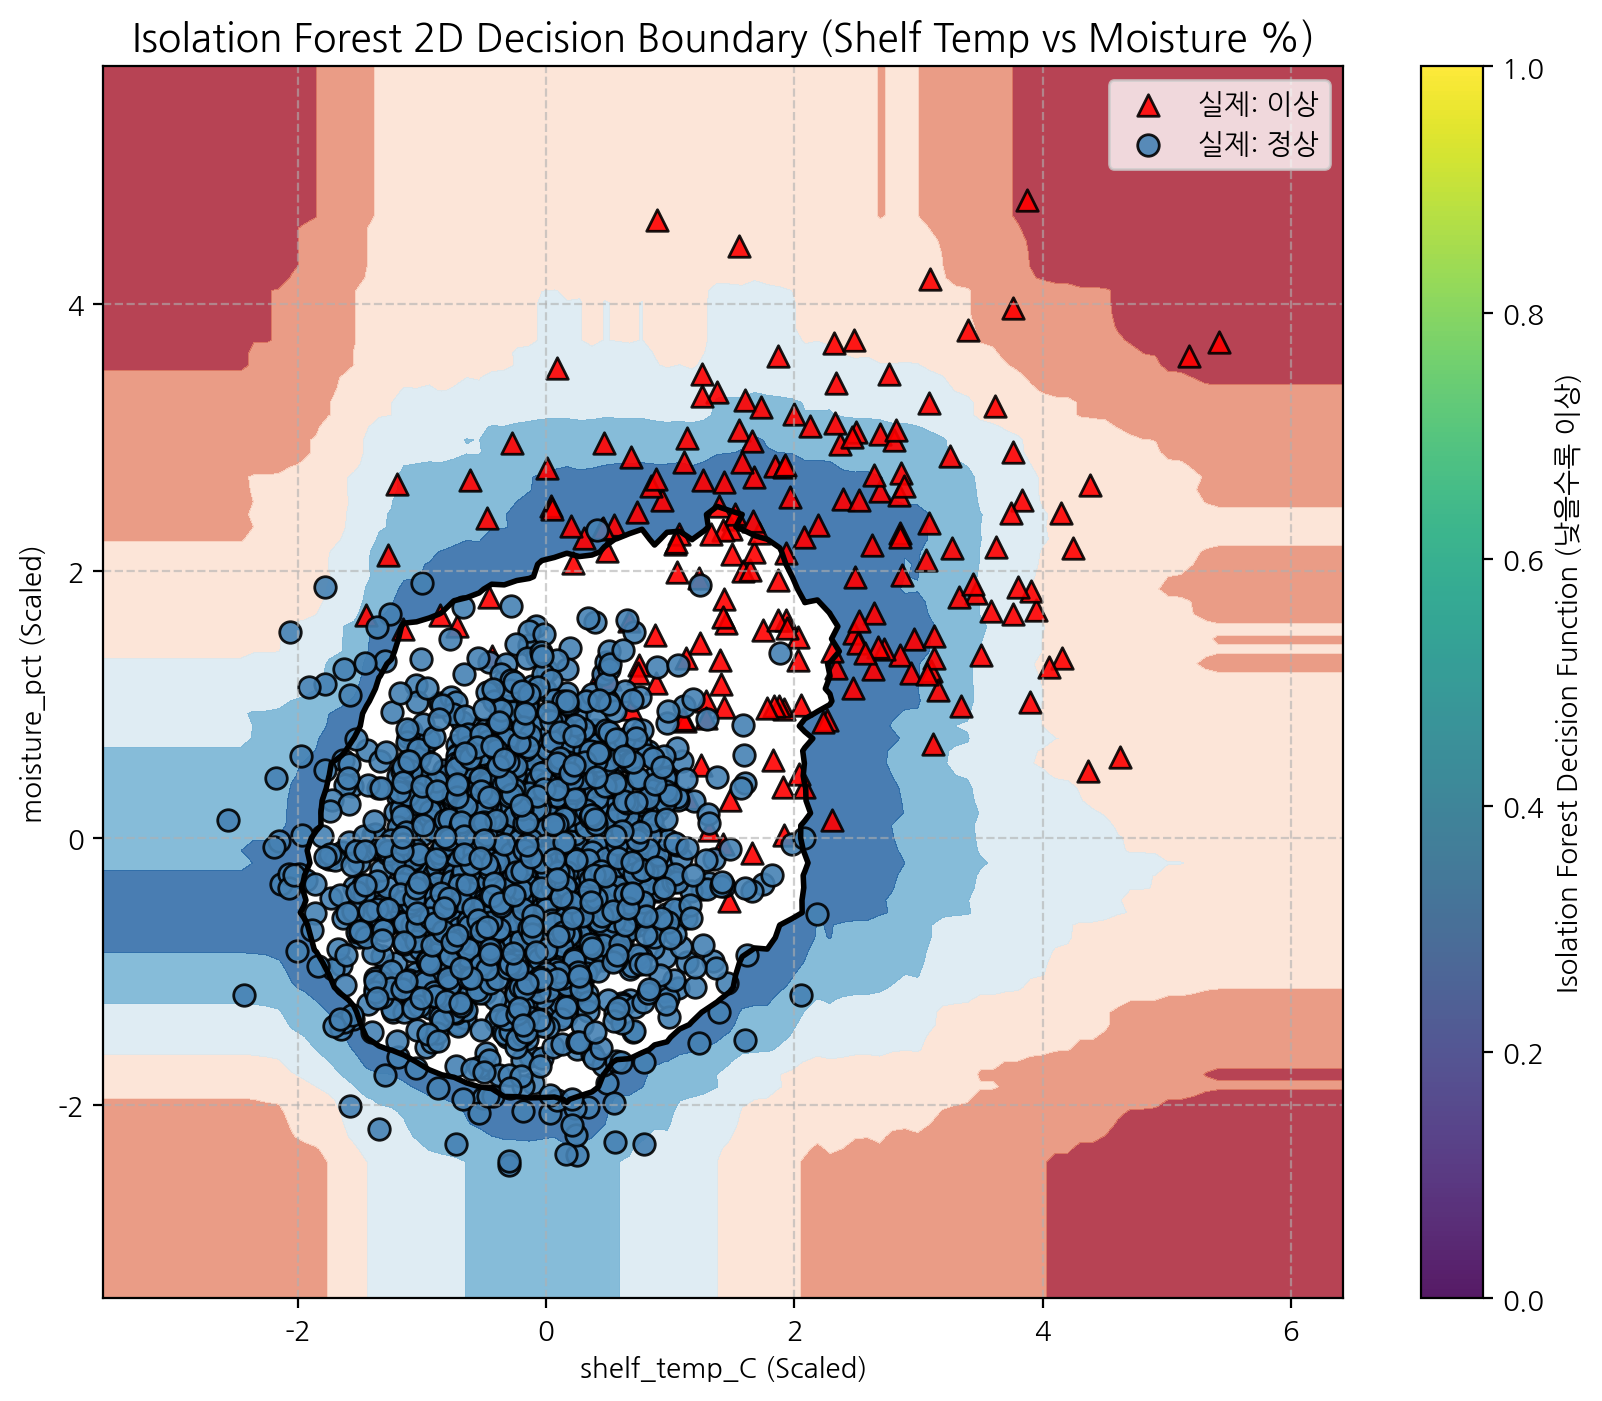

📊 2D Isolation Forest 시각화 완료!
   빨간색 영역이 Isolation Forest가 이상치로 판단하는 경향이 있는 영역입니다.
   실제 이상치(빨간색 삼각형)가 해당 영역에 잘 고립되는 것을 확인할 수 있습니다.


In [19]:
# ─────────────────────────────────────────────────────
# 4-4. 2개 파라미터로 Isolation Forest 동작 시각화
# ─────────────────────────────────────────────────────

# ── 2개 파라미터만 선택 ──
two_features = ['shelf_temp_C', 'moisture_pct']
X_2d_viz = df_lyoph[two_features]

# ── 표준 스케일링 ──
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d_viz)

# ── Isolation Forest 모델 학습 (2D 데이터) ──
iso_forest_2d = IsolationForest(
    n_estimators=100,
    contamination=0.1, # 예시와 동일한 contamination 사용
    random_state=42
)
iso_forest_2d.fit(X_2d_scaled)

# ── 시각화를 위한 그리드 생성 ──
# 각 축의 최소/최대 값을 기준으로 그리드 생성
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# 그리드 상의 모든 점에 대해 이상 점수 예측
Z = iso_forest_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ── 시각화 ──
plt.figure(figsize=(10, 8))

# 이상 점수(decision_function)를 등고선으로 표현
# decision_function 값이 낮을수록 이상치에 가까움 (음수값)
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.RdBu,
             alpha=0.8)
# 경계선 (decision_function 값이 0이 되는 지점) 표시
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')

# 실제 데이터 포인트 표시
# '정상'은 파란색 동그라미, '이상'은 빨간색 삼각형
colors_true = {'정상': 'steelblue', '이상': 'red'}
markers_true = {'정상': 'o', '이상': '^'}

for label, group_df in df_lyoph.groupby('true_label'):
    idx = group_df.index
    plt.scatter(X_2d_scaled[idx, 0],
                X_2d_scaled[idx, 1],
                c=colors_true[label],
                marker=markers_true[label],
                s=60, label=f'실제: {label}', alpha=0.9, edgecolor='black')

plt.title('Isolation Forest 2D Decision Boundary (Shelf Temp vs Moisture %)', fontsize=14)
plt.xlabel(f'{two_features[0]} (Scaled)')
plt.ylabel(f'{two_features[1]} (Scaled)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.colorbar(label='Isolation Forest Decision Function (낮을수록 이상)')
plt.show()

print("📊 2D Isolation Forest 시각화 완료!")
print("   빨간색 영역이 Isolation Forest가 이상치로 판단하는 경향이 있는 영역입니다.")
print("   실제 이상치(빨간색 삼각형)가 해당 영역에 잘 고립되는 것을 확인할 수 있습니다.")

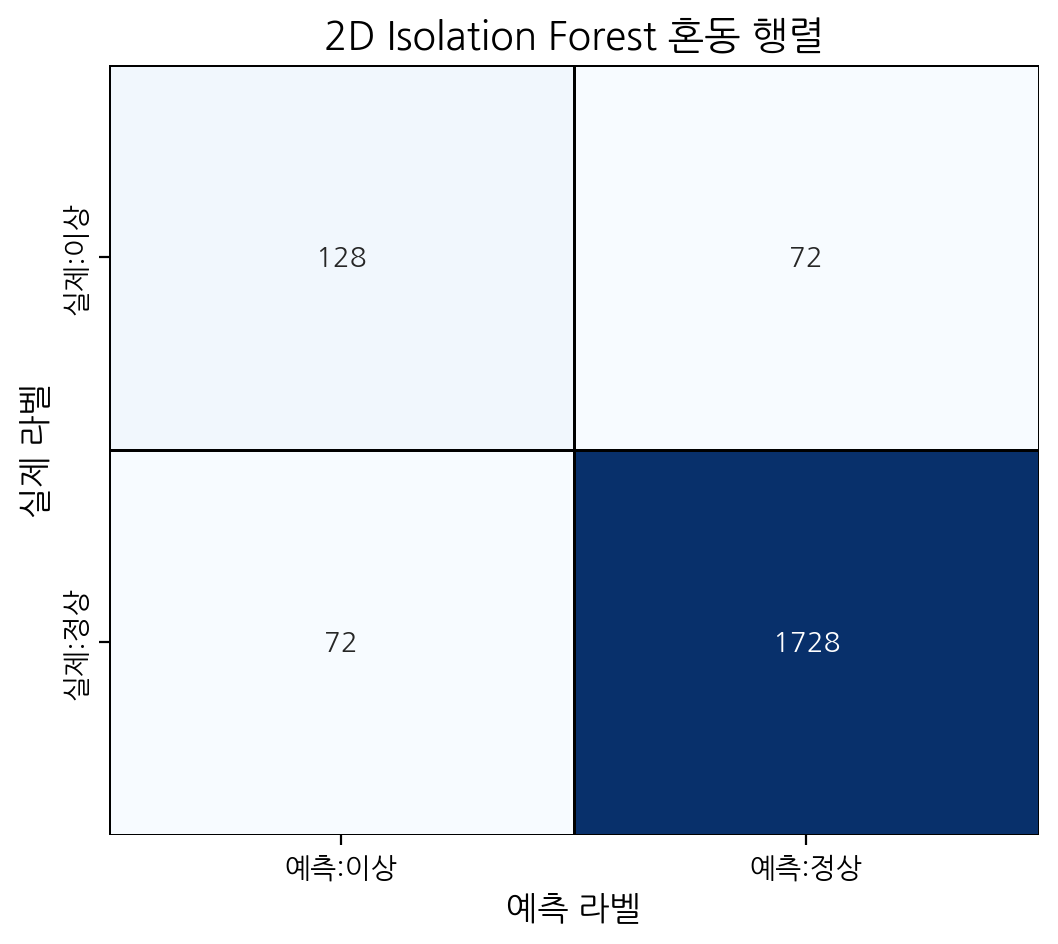

📊 2D Isolation Forest 혼동 행렬 시각화 완료!
   실제 이상치와 예측된 이상치 간의 관계를 확인할 수 있습니다.

📈 2D Isolation Forest 모델 성능 보고서
              precision    recall  f1-score   support

          이상       0.64      0.64      0.64       200
          정상       0.96      0.96      0.96      1800

    accuracy                           0.93      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.93      0.93      0.93      2000



In [20]:
# ─────────────────────────────────────────────────────
# 4-5. 2개 파라미터 모델의 혼동 행렬 추가
# ─────────────────────────────────────────────────────

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 2D 모델의 예측 결과 준비 ──
# iso_forest_2d 모델은 이전에 X_2d_scaled 데이터로 학습되었습니다.
# X_2d_scaled에 대한 예측을 다시 수행합니다.
predictions_2d = iso_forest_2d.predict(X_2d_scaled)
pred_label_2d = pd.Series(predictions_2d).map({1: '정상', -1: '이상'}) # 예측 라벨

# ── 혼동 행렬 계산 ──
# 실제 라벨은 df_lyoph['true_label']을 사용합니다.
cm_2d = confusion_matrix(df_lyoph['true_label'], pred_label_2d,
                         labels=['이상', '정상'])

# ── 혼동 행렬 시각화 ──
plt.figure(figsize=(6, 5))
sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['예측:이상', '예측:정상'],
            yticklabels=['실제:이상', '실제:정상'],
            linewidths=.5, linecolor='black')

plt.title('2D Isolation Forest 혼동 행렬', fontsize=14)
plt.xlabel('예측 라벨', fontsize=12)
plt.ylabel('실제 라벨', fontsize=12)
plt.show()

print("📊 2D Isolation Forest 혼동 행렬 시각화 완료!")
print("   실제 이상치와 예측된 이상치 간의 관계를 확인할 수 있습니다.")

# 추가로 classification_report도 출력하여 상세 성능 확인
from sklearn.metrics import classification_report
print("\n" + "=" * 50)
print("📈 2D Isolation Forest 모델 성능 보고서")
print("=" * 50)
print(classification_report(df_lyoph['true_label'], pred_label_2d,
                            target_names=['이상', '정상']))

### 🌟 비교: RandomForestClassifier (지도 학습) 성능

Isolation Forest는 비지도 학습 모델이었지만, 만약 `true_label`과 같은 정답 라벨을 알고 있다면 지도 학습 모델인 `RandomForestClassifier`를 사용하여 분류 작업을 수행할 수 있습니다. 동일한 2개의 파라미터(`shelf_temp_C`, `moisture_pct`)와 `true_label`을 이용하여 `RandomForestClassifier`를 학습시키고 그 성능을 비교해봅니다.

📈 RandomForestClassifier 모델 성능 보고서
              precision    recall  f1-score   support

          이상       0.82      0.85      0.84        60
          정상       0.98      0.98      0.98       540

    accuracy                           0.97       600
   macro avg       0.90      0.91      0.91       600
weighted avg       0.97      0.97      0.97       600



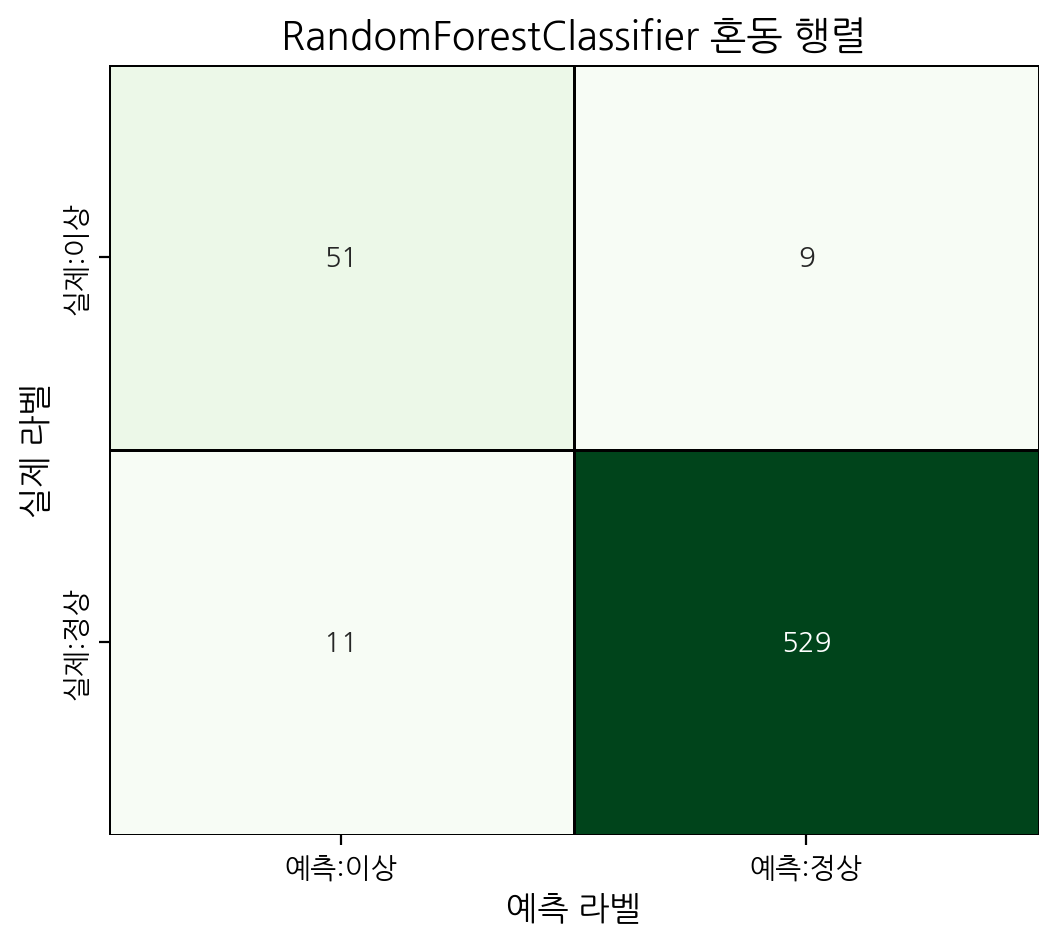

📊 RandomForestClassifier 학습 및 평가 완료!
   Isolation Forest (비지도 학습)와 RandomForestClassifier (지도 학습)의 성능을 비교해 보세요.


In [14]:
# ─────────────────────────────────────────────────────
# 4-6. RandomForestClassifier (지도 학습) 모델 학습 및 평가
# ─────────────────────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ── 데이터 준비 (2D 특성 및 정답 라벨) ──
X_rf = X_2d_scaled # 이전에 표준화된 2D 데이터 재사용
y_rf = df_lyoph['true_label']

# ── 훈련/테스트 데이터 분리 ──
# 모델이 학습하지 않은 데이터로 성능을 평가하기 위해 분리
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.3, random_state=42, stratify=y_rf)

# ── RandomForestClassifier 모델 학습 ──
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # class_weight로 클래스 불균형 처리
rf_model.fit(X_train, y_train)

# ── 예측 ──
y_pred_rf = rf_model.predict(X_test)

# ── 성능 평가 ──
print("=" * 50)
print("📈 RandomForestClassifier 모델 성능 보고서")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['이상', '정상']))

# ── 혼동 행렬 시각화 ──
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['이상', '정상'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['예측:이상', '예측:정상'],
            yticklabels=['실제:이상', '실제:정상'],
            linewidths=.5, linecolor='black')

plt.title('RandomForestClassifier 혼동 행렬', fontsize=14)
plt.xlabel('예측 라벨', fontsize=12)
plt.ylabel('실제 라벨', fontsize=12)
plt.show()

print("📊 RandomForestClassifier 학습 및 평가 완료!")
print("   Isolation Forest (비지도 학습)와 RandomForestClassifier (지도 학습)의 성능을 비교해 보세요.")

---
## ✅ 예제 4 핵심 요약

| 항목 | 내용 |
|------|------|
| **GMP 적용** | ICH Q9 리스크 관리 · 다변량 이상 이벤트 자동 감지 |
| **AI 기법** | Isolation Forest · PCA 2D 시각화 · 스크리 플롯 |
| **핵심 성과** | 레이블 없이 이상 배치 자동 식별 · 이상 점수(anomaly score) 분포 |
| **다음 단계** | 이상 감지 → 예제 5(Deviation 분류)로 이상 유형 자동 분류 |

> 💡 **기억할 한 줄**: "이상 데이터는 정상보다 '고립시키기 쉽다' — Isolation Forest의 동작원리."